In [3]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

# models = list_models('vllm') + ['siglip2_so400_16_512']
models = list_models('vllm') + ['siglip2_so400_16_256']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs', download_all_precomputed=False)

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("capability")
results["capability"] = results["benchmark_name"].map(benchmark_mappings)
benchmark_mappings = get_benchmark_mappings("num_classes")
results["num_classes"] = results["benchmark_name"].map(benchmark_mappings)

results = results[(results['task_name'] == 'multi_choice_classification') | (results['model_name'].str.contains('SigLIP')) | (results['task_name'] == 'multi_choice_relation')]

File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/caltech101.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cars.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar10.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar100.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_count.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_distance.f
File not found:  /home/haltahan6/unibench/outpu

/tmp/ipykernel_3946431/3377660876.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3946431/3377660876.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=90, ha='right')
/tmp/ipykernel_3946431/3377660876.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3946431/3377660876.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels, rotation=90, ha='right')
/tmp/ipykernel_3946431/3377660876.py:39: FutureWarning: 

Passing 

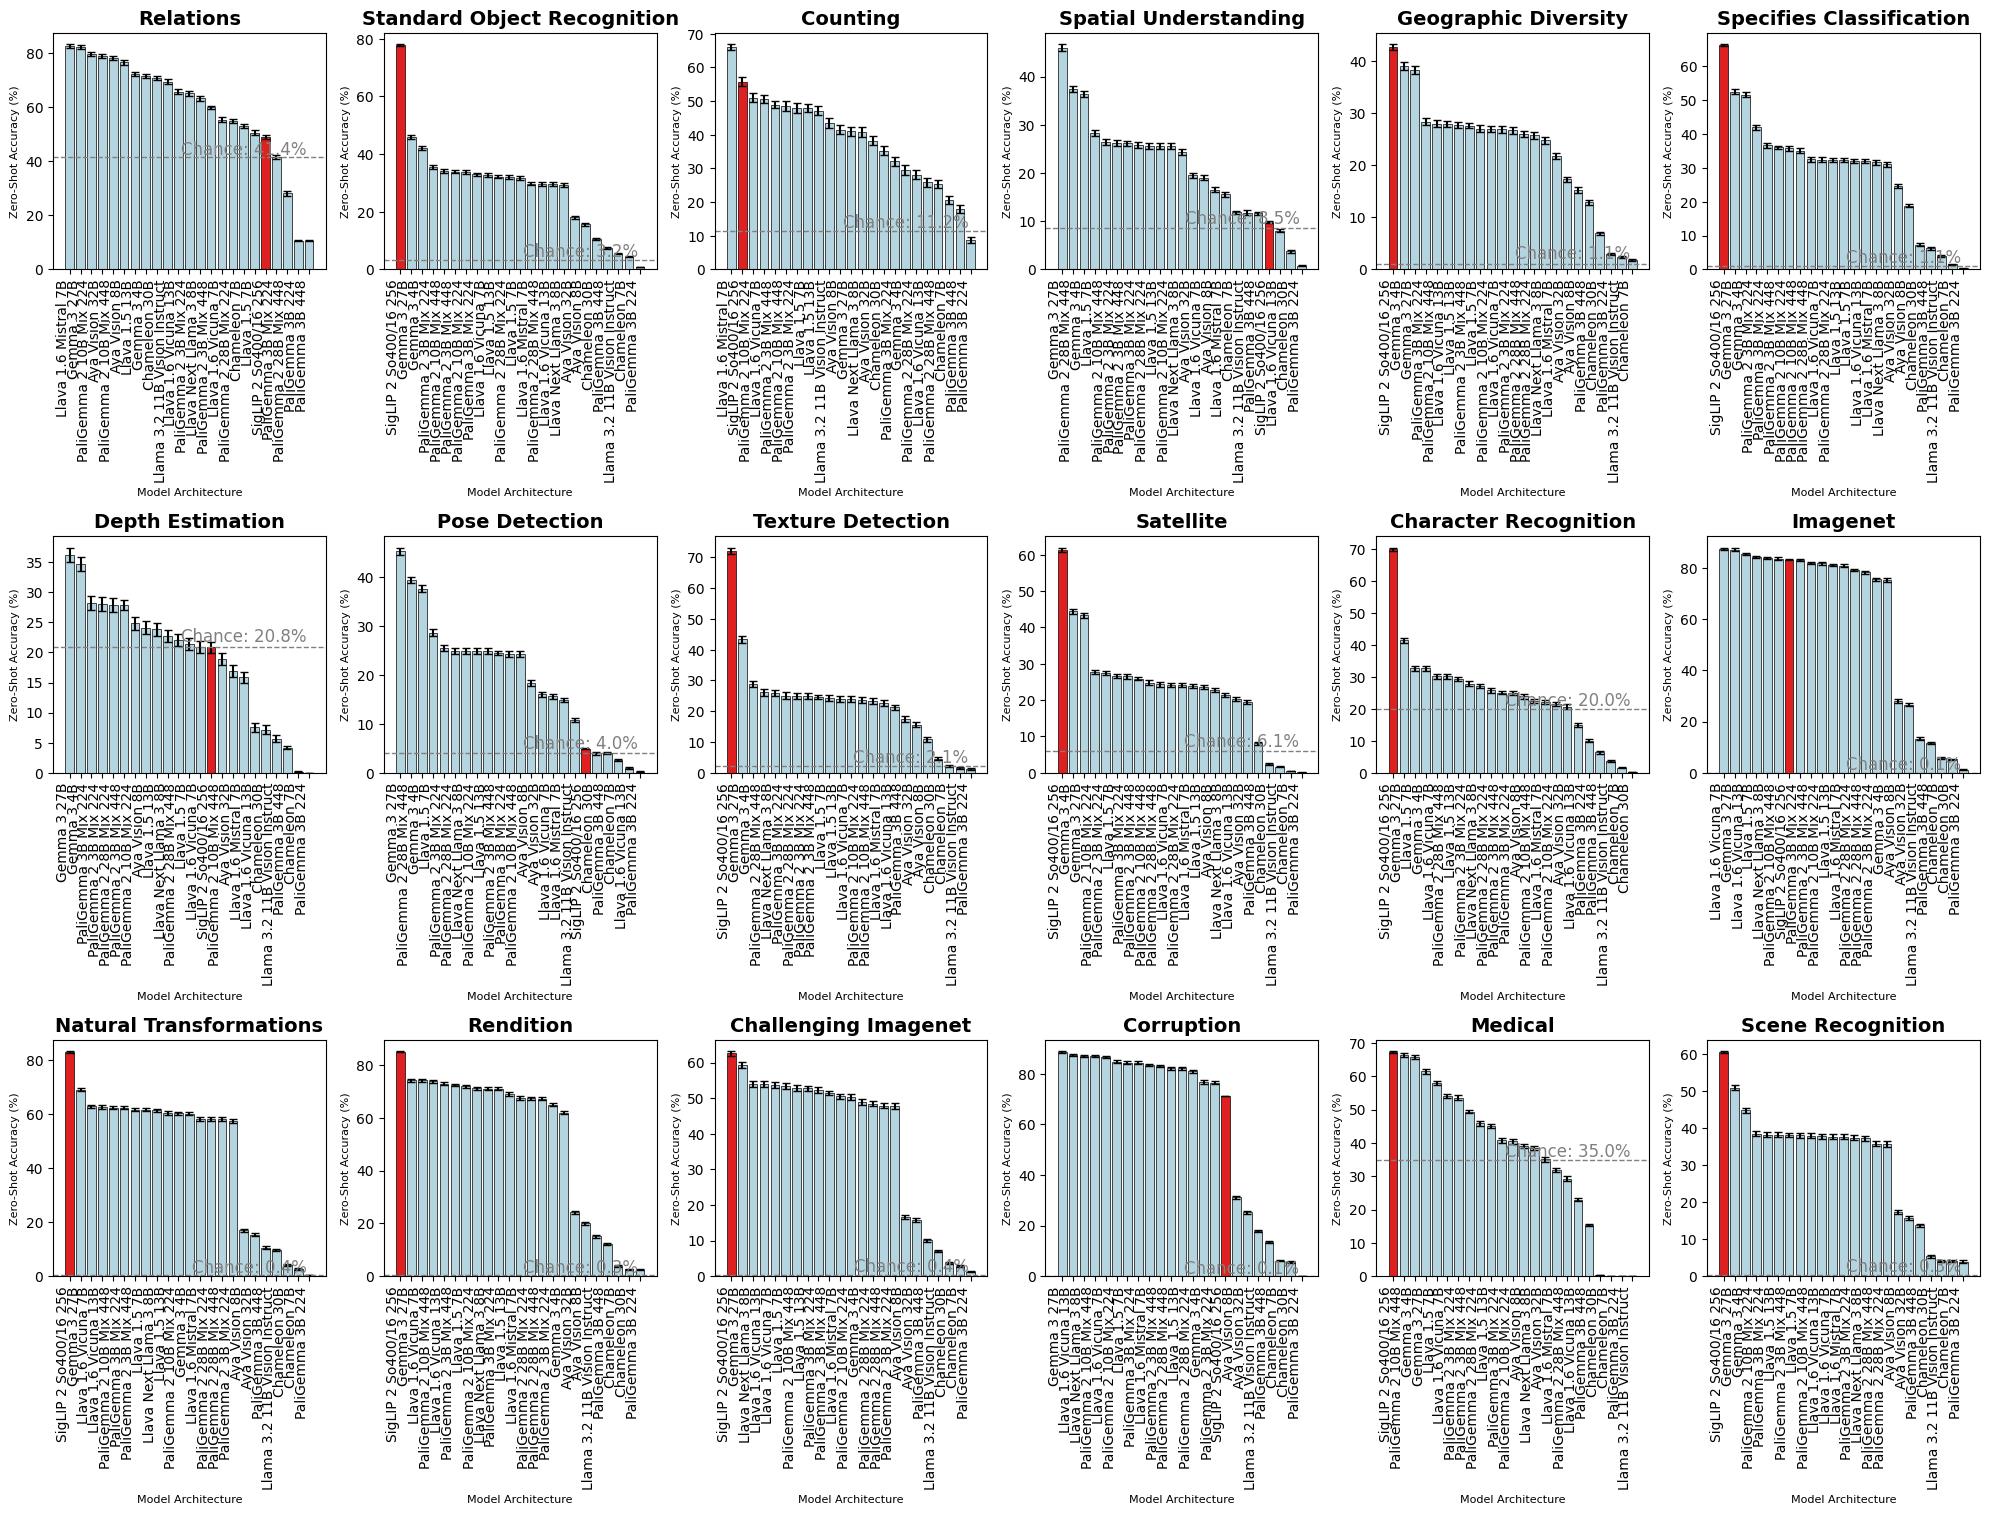

In [4]:
# --- Styling ---
LABEL_FONT_SIZE = 8
TICK_FONT_SIZE = 12
TITLE_FONT_SIZE = 14
ANNOTATION_FONT_SIZE = 12

# Get unique benchmark types
benchmark_types = results['capability'].unique()

# Create subplots
fig, axes = plt.subplots(4, 6, figsize=(20, 18))
axes = axes.flatten()

for i, bench_type in enumerate(benchmark_types):
    # Filter data for this benchmark type
    type_results = results[results['capability'] == bench_type]
    
    # Compute average and SEM for this benchmark type
    df_mean_type = type_results.groupby(["model_name", "benchmark_name"]).correctness.mean()
    df_sem_type = type_results.groupby(["model_name", "benchmark_name"]).correctness.sem()
    
    type_performance = df_mean_type.reset_index().groupby("model_name").correctness.mean() * 100
    type_sem = df_sem_type.reset_index().groupby("model_name").correctness.mean() * 100
    
    type_model_data = pd.DataFrame({
        'model_name': type_performance.index,
        'performance': type_performance.values,
        'sem': type_sem.values
    })
    
    # Sort by performance
    sorted_type_models = type_model_data.sort_values('performance', ascending=False)
    
    # Create colors: red for SigLIP, light blue for others
    colors = ['red' if 'SigLIP' in name else 'lightblue' for name in sorted_type_models['model_name']]
    
    # Create barplot for this subplot
    ax = axes[i]
    sns.barplot(
        data=sorted_type_models,
        x='model_name',
        y='performance',
        palette=colors,
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )
    
    # Add error bars
    for j, row in enumerate(sorted_type_models.itertuples()):
        ax.errorbar(j, row.performance, yerr=row.sem, fmt='none', color='black',
                   capsize=3, elinewidth=1.5)
    
    # Customize this subplot
    ax.set_xlabel('Model Architecture', fontsize=LABEL_FONT_SIZE)
    ax.set_ylabel('Zero-Shot Accuracy (%)', fontsize=LABEL_FONT_SIZE)
    ax.set_title(f'{bench_type.title()}', fontsize=TITLE_FONT_SIZE, weight='bold')
    
    # Format x-axis labels
    tick_labels = [name.split('_')[-1] if '_' in name else name for name in sorted_type_models['model_name']]
    ax.set_xticklabels(tick_labels, rotation=90, ha='right')
    
    # Compute chance level as average (1/num_classes) across benchmarks within this capability
    capability_benchmarks = type_results['benchmark_name'].unique()
    chance_levels = []
    for benchmark in capability_benchmarks:
        num_classes = benchmark_mappings[benchmark]
        chance_levels.append((1/num_classes) * 100)
    chance_level = sum(chance_levels) / len(chance_levels)
    
    # Add chance level line
    ax.axhline(chance_level, linestyle='--', color='gray', linewidth=1)
    ax.text(len(sorted_type_models) - 1.2, chance_level + 1,
            f'Chance: {chance_level:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
            color='gray', ha='right')

# Hide any unused subplots
for i in range(len(benchmark_types), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()
